In [1]:
import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import scFates as scf
sc.set_figure_params(dpi=150)

In [2]:
adata=sc.read("/home/matei/data/adata_neuroblastoma_assigned.h5ad")

In [3]:
adata=adata[~adata.obs.leiden.isin(["7","10","11","6","11","8"])]

In [126]:
import pandas as pd
df = pd.read_csv("/home/matei/data/dui_leiden.csv")

transcripts = df["transcript_name"].dropna().unique().tolist()

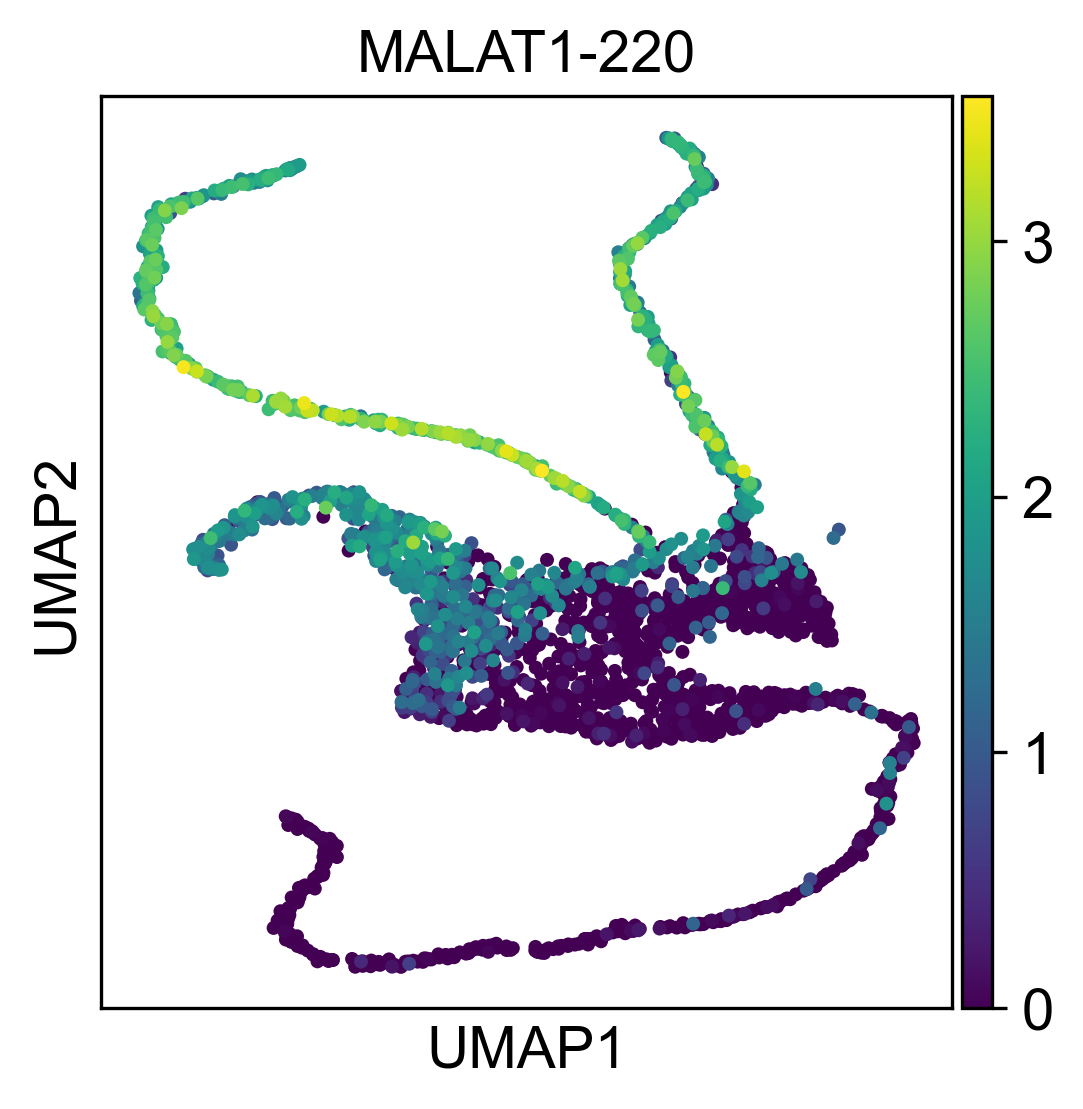

ACTB-201 not found
GAPDH-202 not found


In [5]:
# Manual check of DUI
transcripts = [
    "MALAT1-220",
    "ACTB-201",
    "GAPDH-202",
]

for tr in transcripts:
    
    # récupérer les features correspondantes
    genes = adata.var.loc[
        adata.var["transcript"] == tr
    ].index.tolist()

    # skip si transcript absent
    if len(genes) == 0:
        print(f"{tr} not found")
        continue

    sc.pl.umap(
        adata,
        color=genes,
        title=tr,
    )

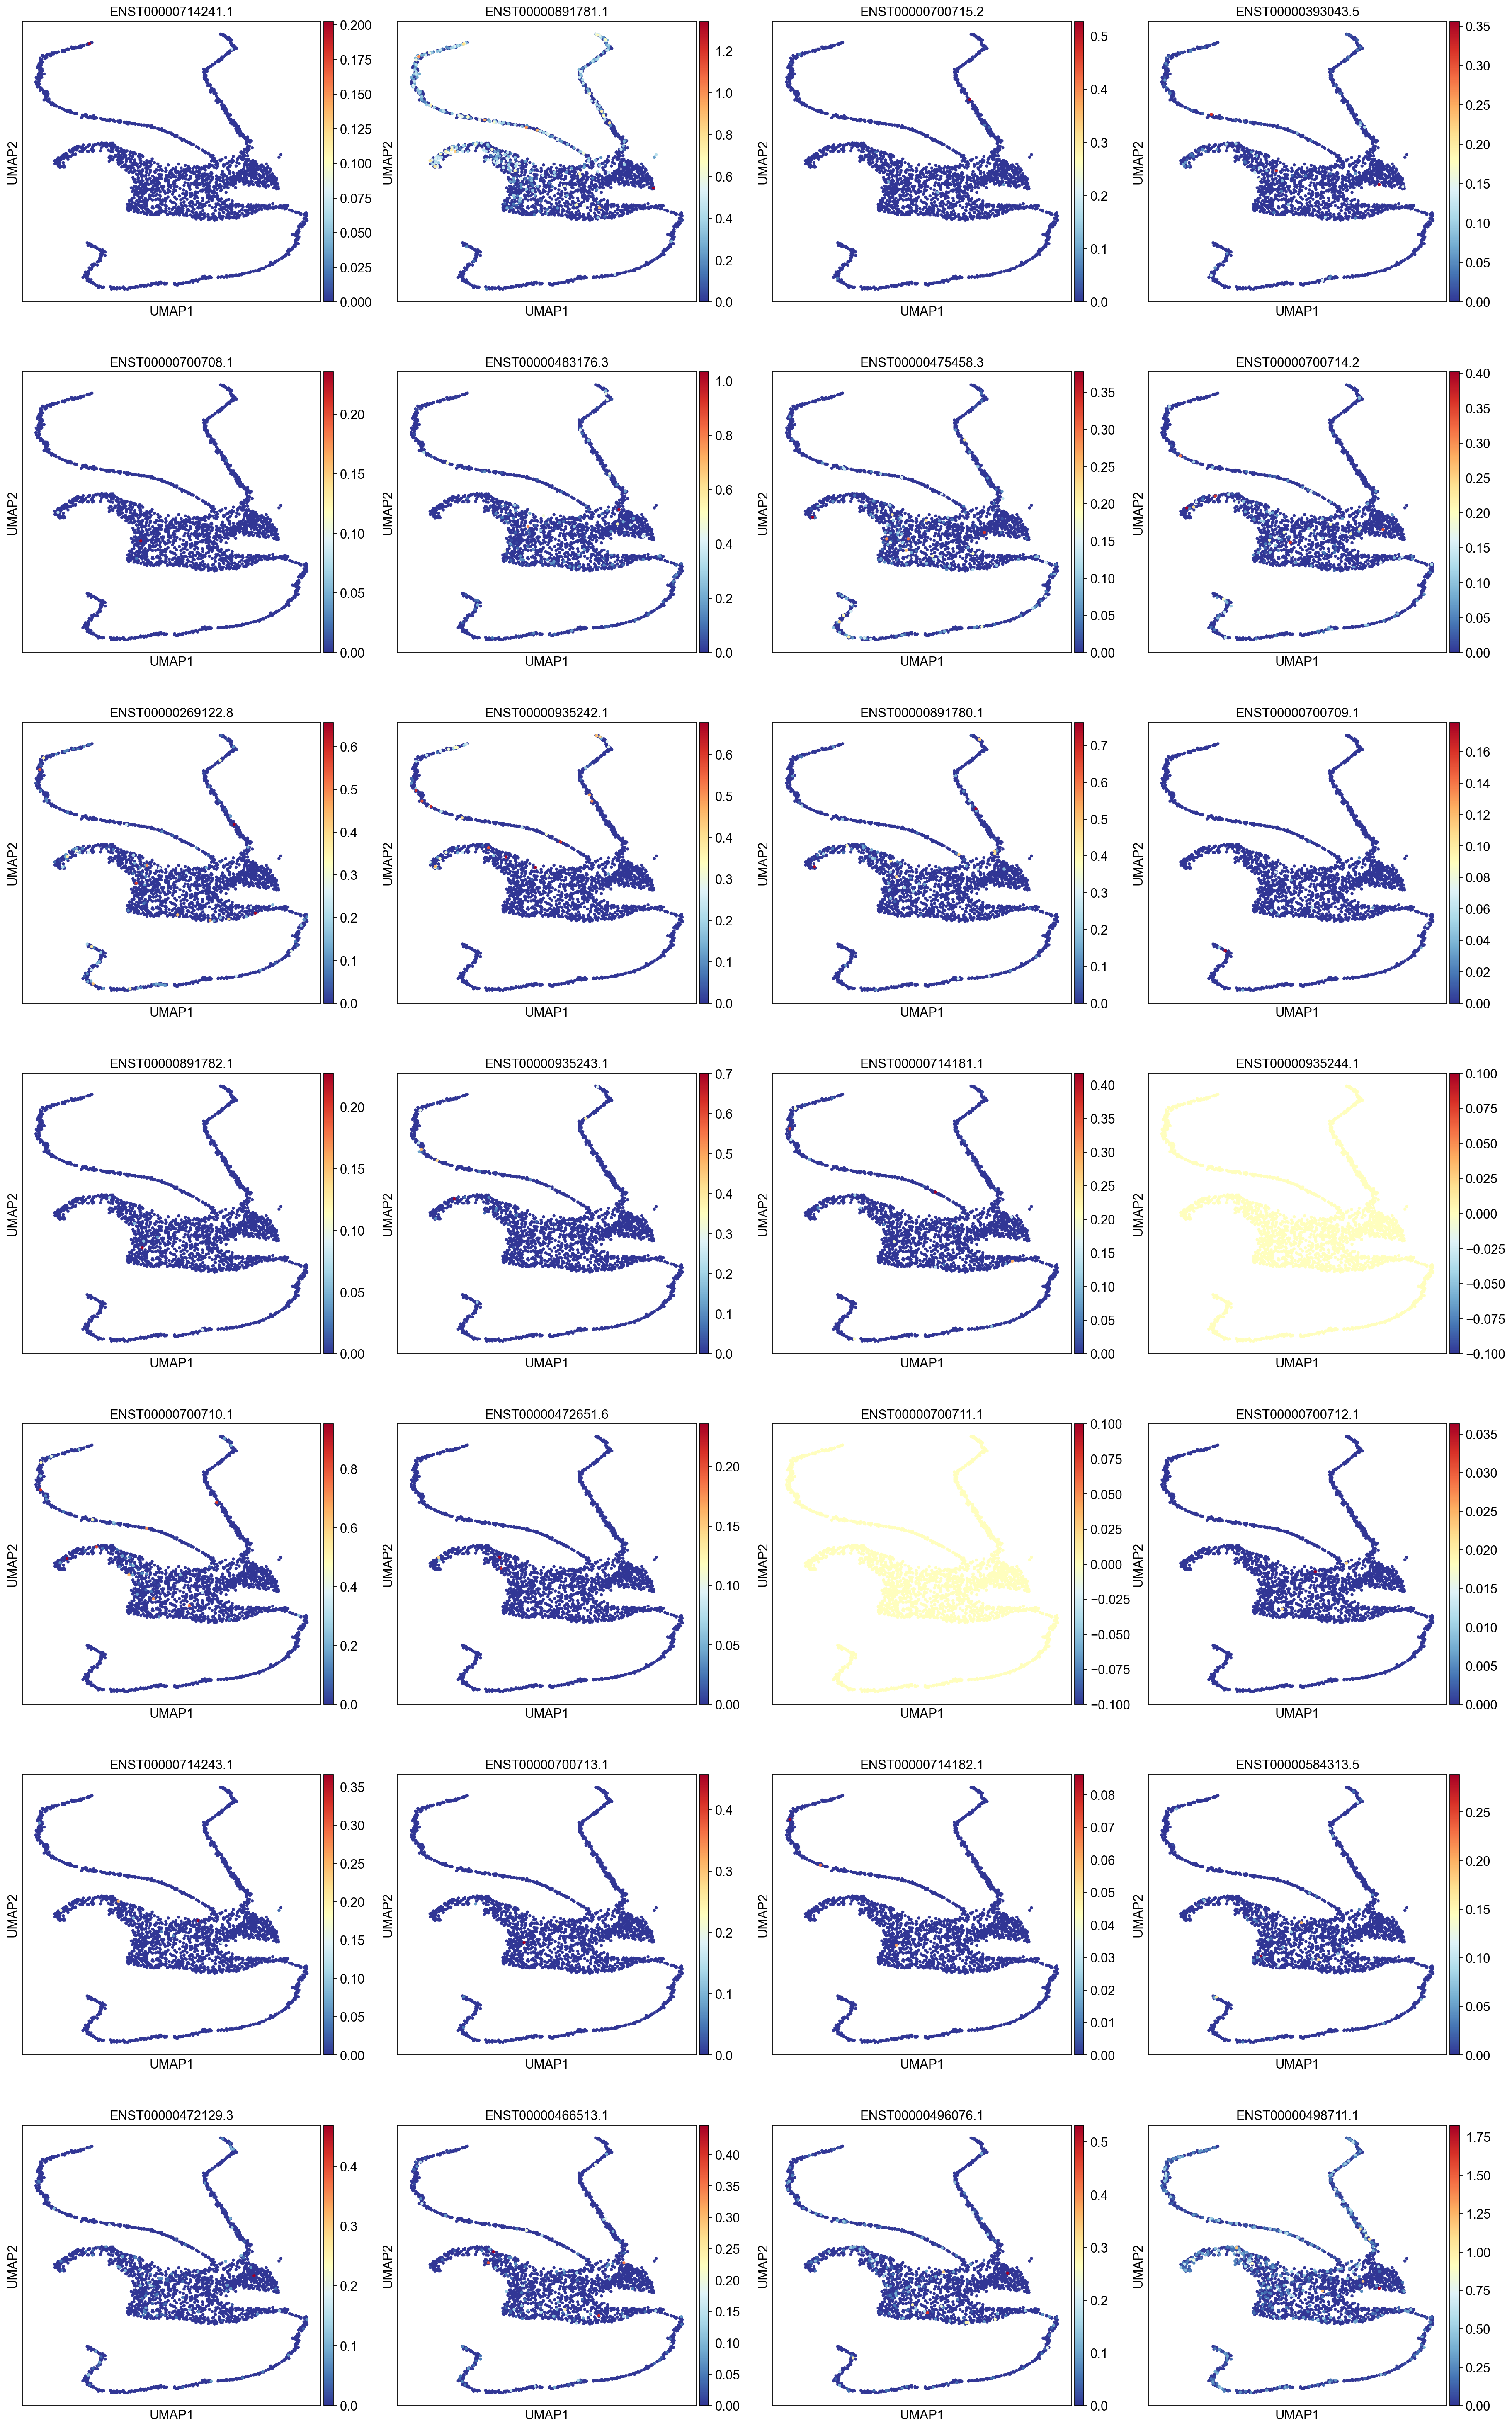

In [72]:
# Plot diff transcripts of a same gene
sc.set_figure_params(figsize=(6,6))

sc.pl.umap(adata,
           color = adata.var[adata.var["gene"]=="CLTC"].index.tolist(),
                           )



## Results - MYCN

In [6]:
sc.settings.set_figure_params(
    dpi=150,
    dpi_save=600,
    vector_friendly=True,
    facecolor=None,
    frameon=False)

/tmp/ipykernel_2977801/1228460758.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[f"sum_exp_{gene}"] = adata[:, transcripts].X.sum(axis=1)


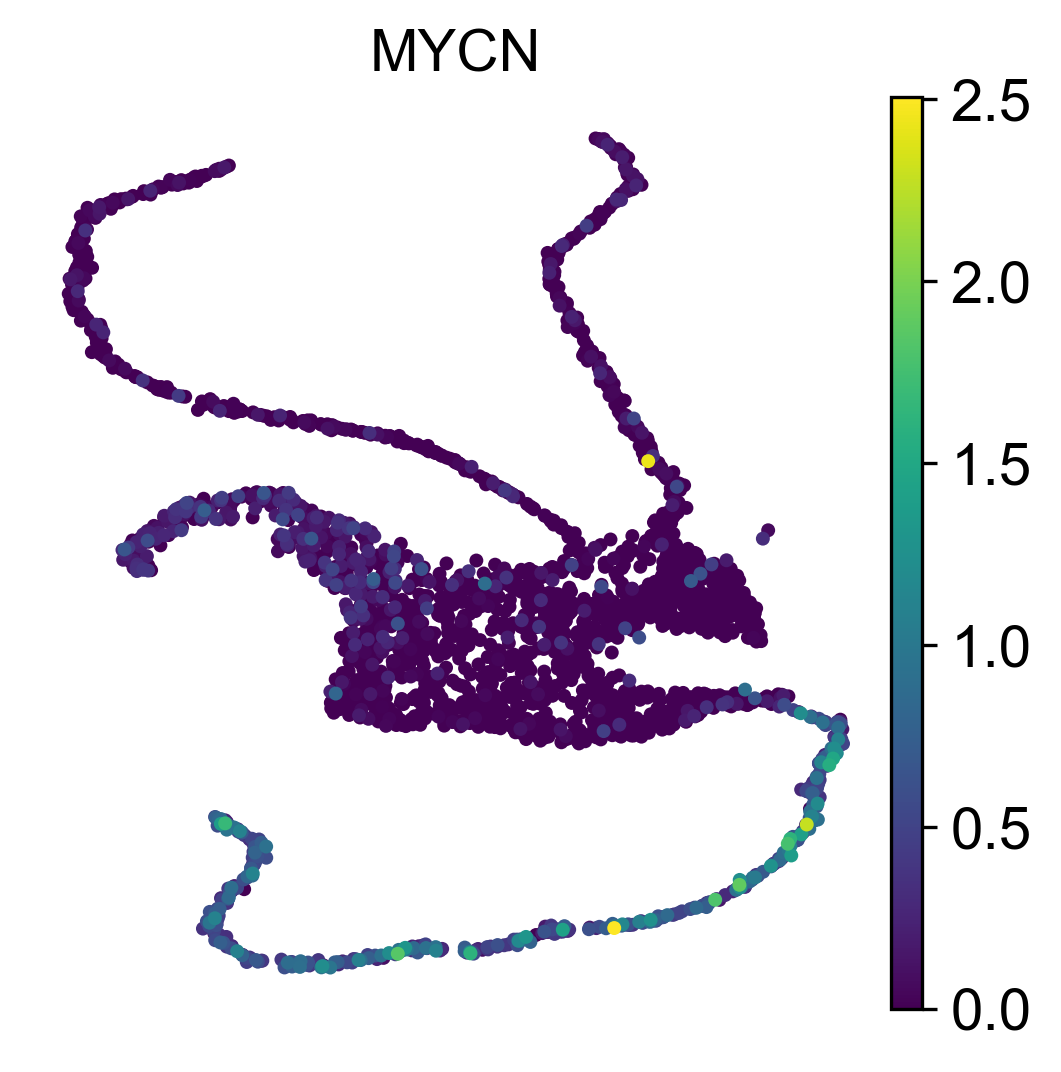

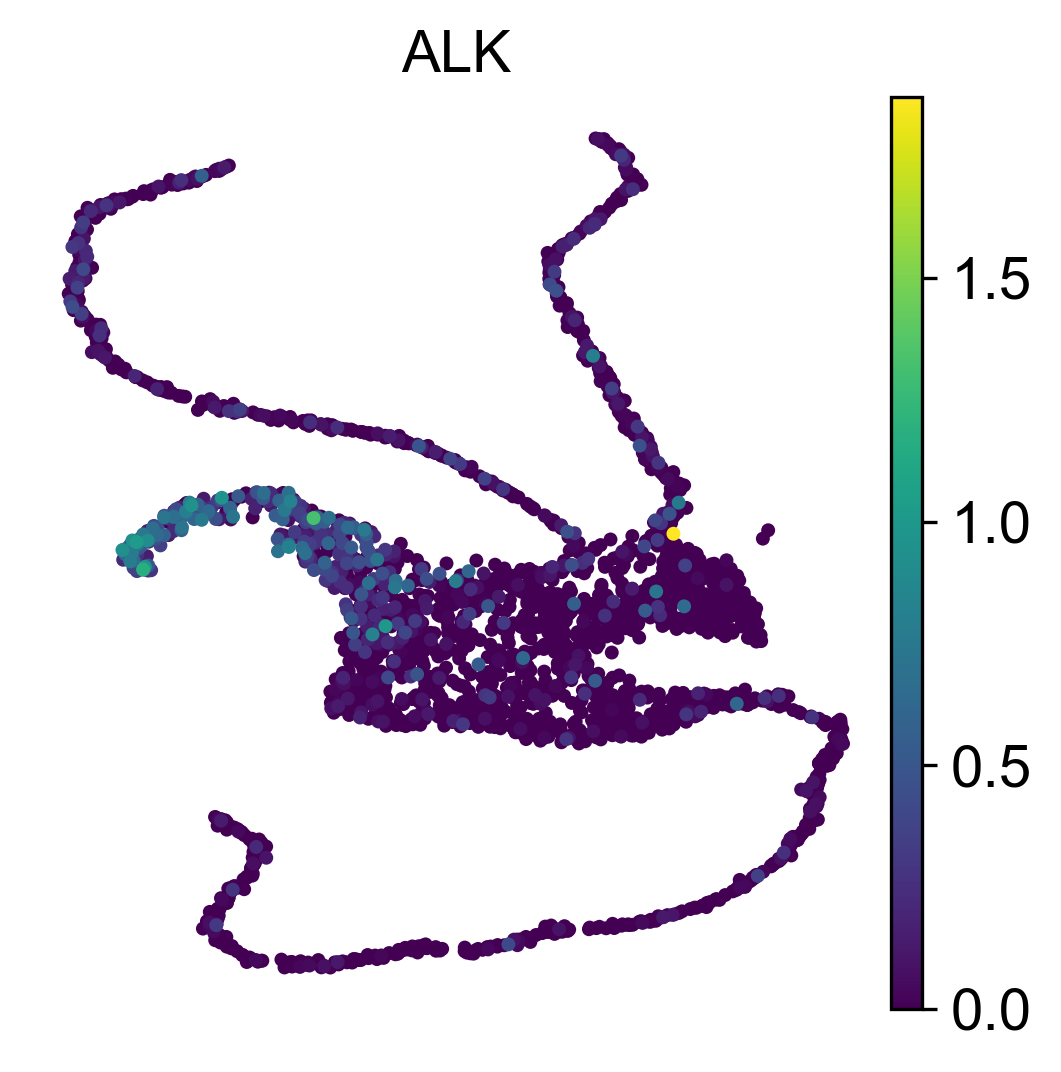

In [8]:
test_genes = ["MYCN","ALK"]

for gene in test_genes:
    transcripts = adata.var[adata.var["gene"] == gene].index
    
    if len(transcripts) == 0:
        print(f"{gene} not found")
        continue
    
    adata.obs[f"sum_exp_{gene}"] = adata[:, transcripts].X.sum(axis=1)
    
    sc.pl.umap(
        adata,
        color=f"sum_exp_{gene}",
        title=gene
    )

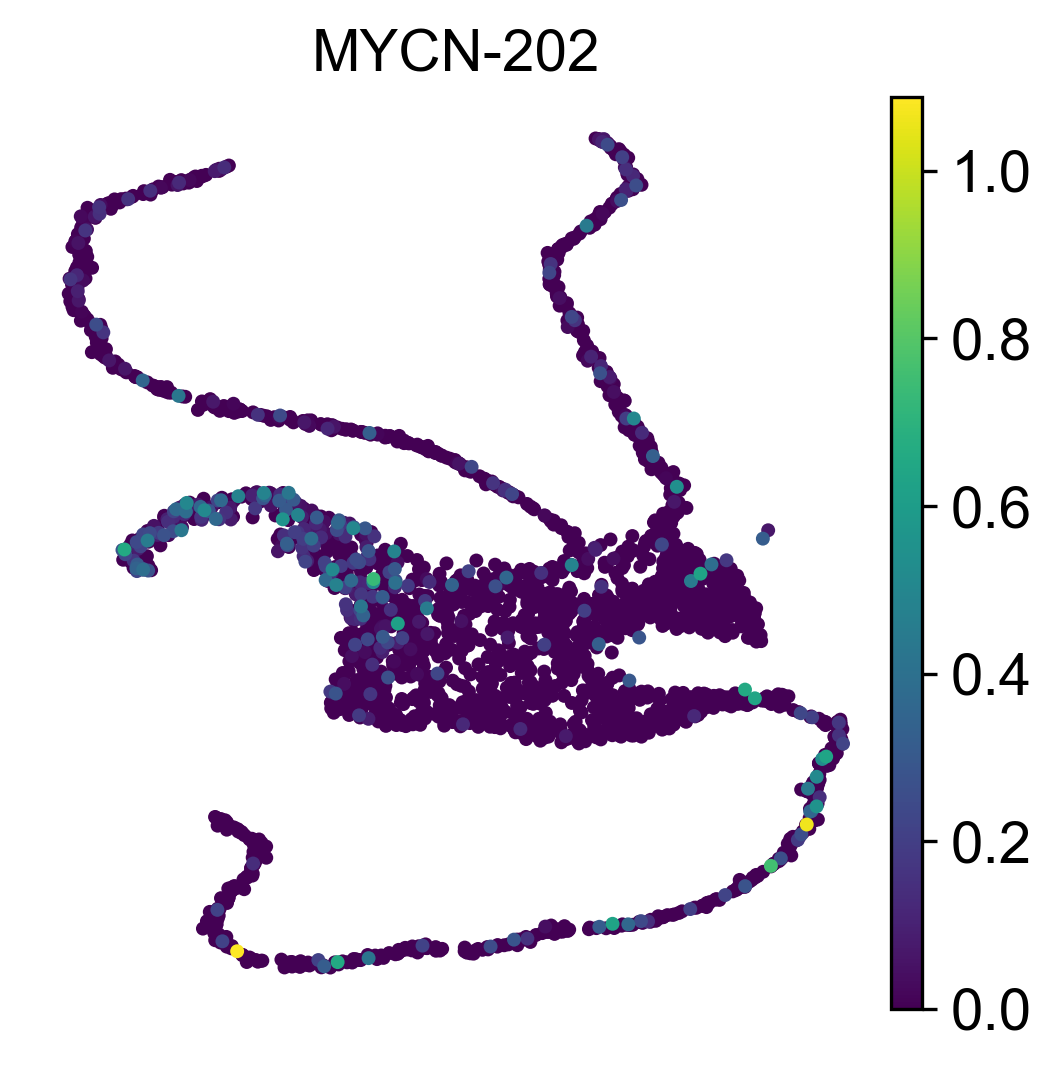

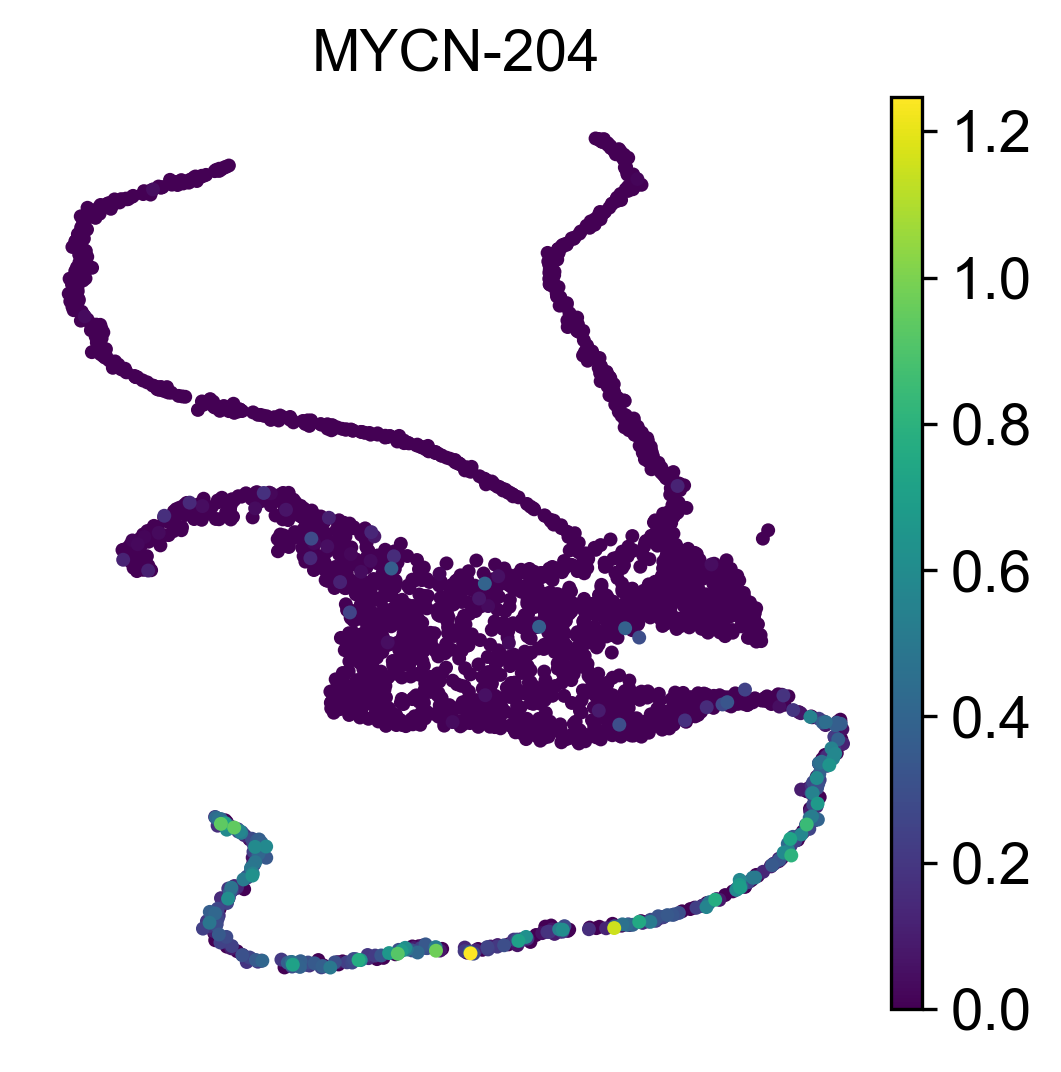

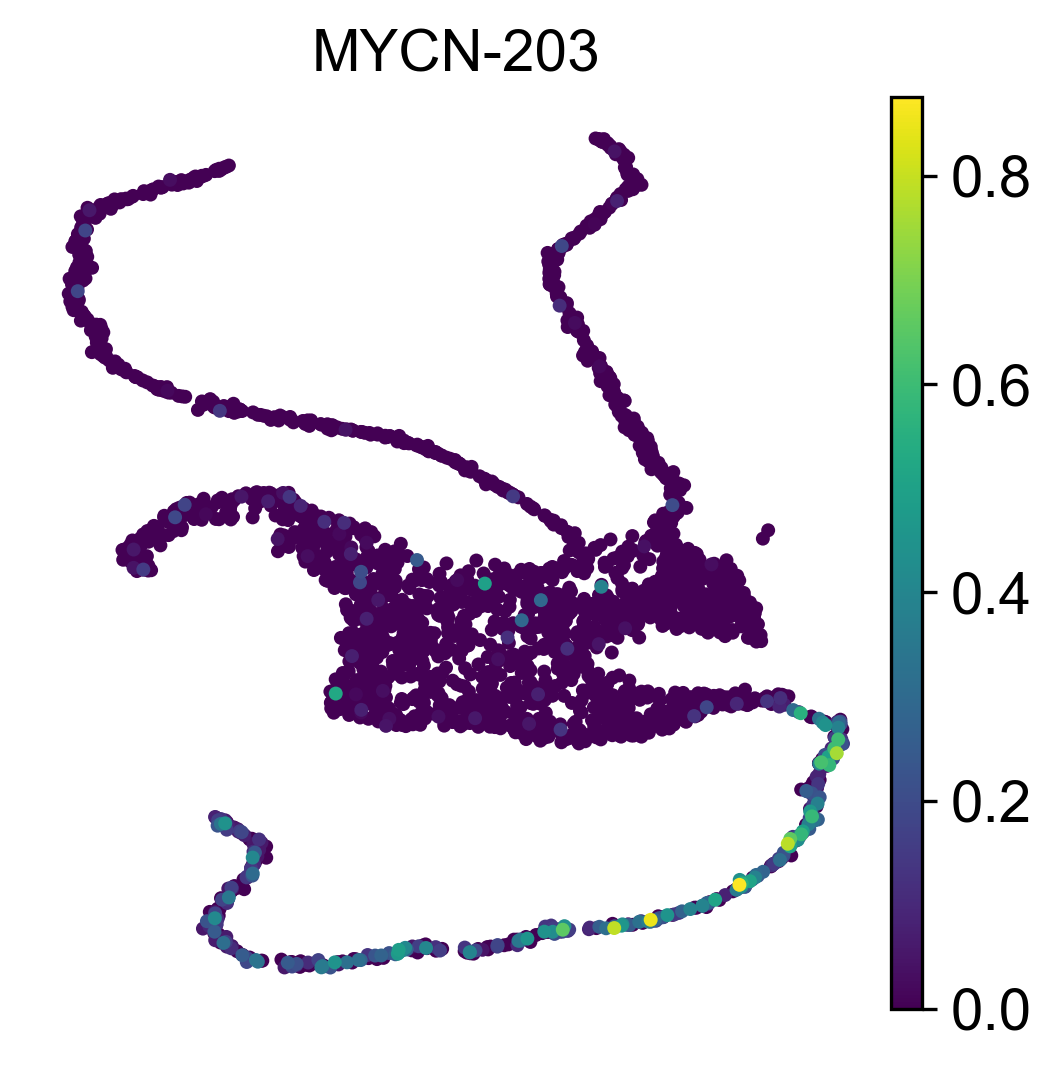

In [10]:
transcripts = [
    "MYCN-202",
    "MYCN-204",
    "MYCN-203",
]

for tr in transcripts:
    
    # récupérer les features correspondantes
    genes = adata.var.loc[
        adata.var["transcript"] == tr
    ].index.tolist()

    # skip si transcript absent
    if len(genes) == 0:
        print(f"{tr} introuvable")
        continue
     
    sc.pl.umap(
        adata,
        color=genes,
        title=tr,
    )

## Plots for report/pres

In [12]:
# Saving directory
sc.settings.figdir = "./figures/04_DUI"

In [13]:
# Parameter for UMAP plots
sc.settings.set_figure_params(
    dpi=150,        
    dpi_save=600,   
    vector_friendly=True,
    format="pdf",
)

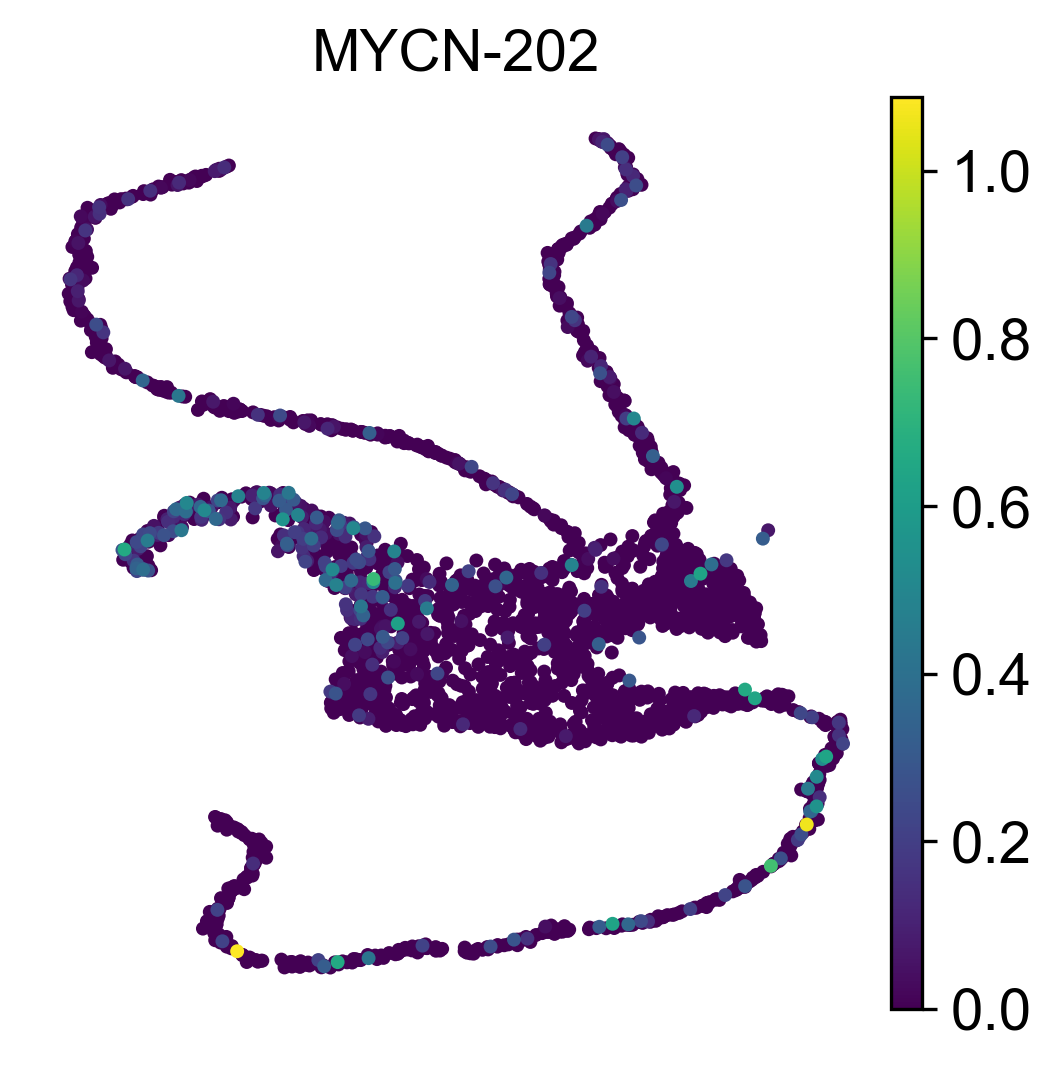

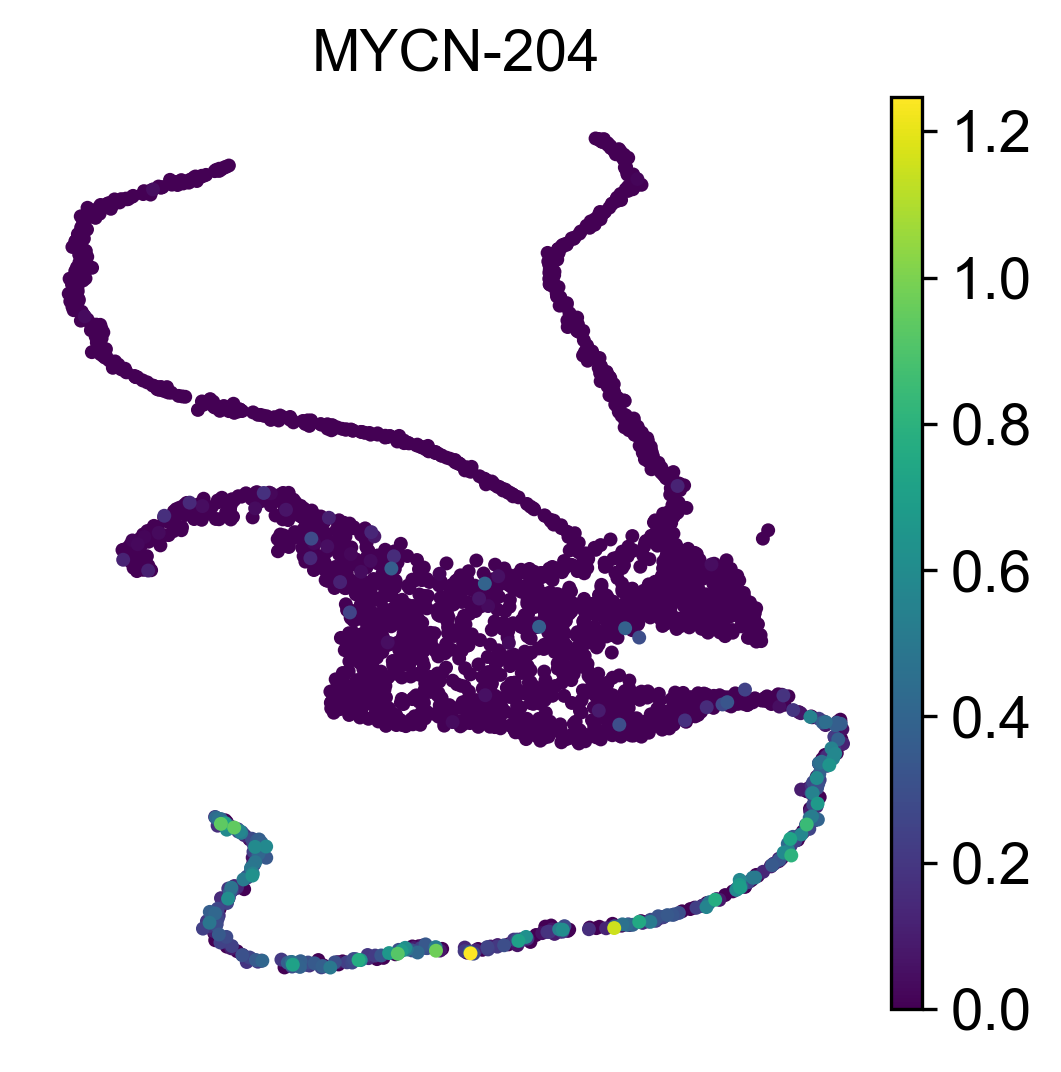

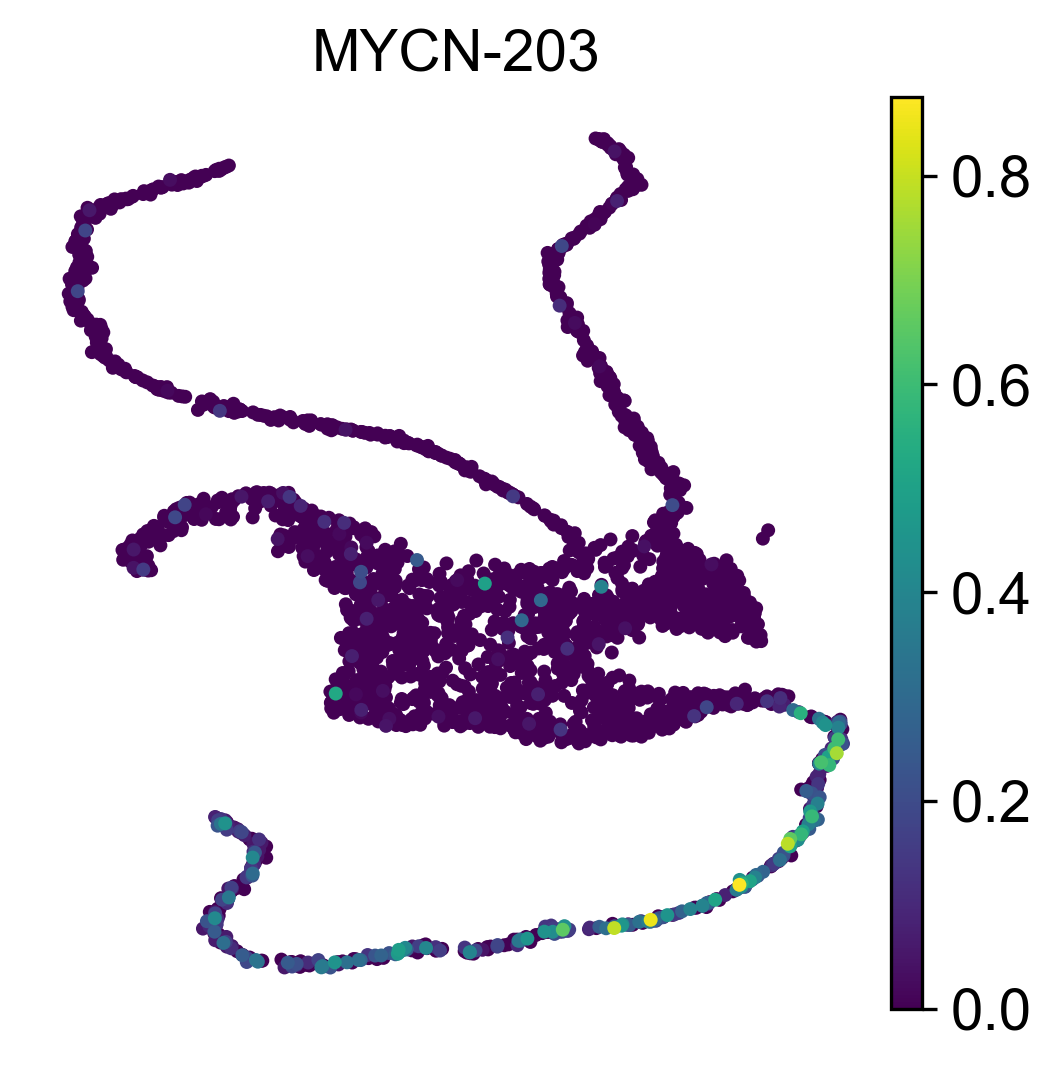

In [14]:
transcripts = [
    "MYCN-202",
    "MYCN-204",
    "MYCN-203",
]

for tr in transcripts:
    
    genes = adata.var.loc[
        adata.var["transcript"] == tr
    ].index.tolist()

    if len(genes) == 0:
        print(f"{tr} introuvable")
        continue
     
    sc.pl.umap(
        adata,
        color=genes,
        title=tr,
        frameon=False,
        save=f"_{tr}.pdf"    
    )